In [6]:
import pandas as pd
import numpy as np

INPUT_PATH = "dataset.csv"
OUTPUT_PATH = "cleaned_dataset.csv"

NUMERIC_RANGE_COLS = {
    # column: (min, max) -- values outside this range are treated as bad data
    "Age": (18, 100),
    "YearsEmployed": (0, 60),
    "Income": (0, 100_000_000),
    "Debt": (0, 100_000_000),
}

# CreditScore can arrive on two different scales depending on the source:
# the raw UCI-style 0-100 scale, or the final bank-style 300-850 scale.
# train_model.py rescales 0-100 up to 300-800 automatically, so cleaning
# just needs to reject values that don't plausibly belong to either scale.
CREDIT_SCORE_VALID_RANGES = [(0, 100), (300, 850)]

BINARY_MAPS = {
    "Gender": {"male": 1, "m": 1, "1": 1, "female": 0, "f": 0, "0": 0},
    "Married": {"yes": 1, "y": 1, "married": 1, "1": 1,
                "no": 0, "n": 0, "single": 0, "not married": 0, "0": 0},
    "BankCustomer": {"yes": 1, "y": 1, "1": 1, "no": 0, "n": 0, "0": 0},
    "PriorDefault": {"no": 1, "n": 1, "1": 1,   # "no default" = good = 1
                      "yes": 0, "y": 0, "0": 0},
}

INDUSTRY_MAP = {
    "other": 0, "it": 1, "information technology": 1, "banking": 2,
    "healthcare": 3, "education": 4, "government": 5, "business": 6,
    "manufacturing": 7,
}

EMPLOYMENT_MAP = {
    "employed": "employed", "self-employed": "self-employed",
    "self employed": "self-employed", "unemployed": "unemployed",
    "student": "student", "retired": "retired",
}

CITIZENSHIP_MAP = {
    "indian": "indian", "india": "indian",
    "nri": "nri", "other": "other",
}

CORE_REQUIRED_COLS = [
    "Gender", "Age", "Debt", "Married", "BankCustomer", "Industry",
    "YearsEmployed", "Employed", "Citizen", "PriorDefault", # Updated column names
    "CreditScore", "Income", "Approved",
]


def clean_text(series):
    return series.astype(str).str.strip().str.lower()


def load_raw(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} columns")
    return df


def report_missing(df, label):
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"\nMissing values ({label}):")
        print(missing.to_string())
    else:
        print(f"\nNo missing values ({label}).")


def strip_string_cells(df):
    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in obj_cols:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"": np.nan, "nan": np.nan, "?": np.nan, "none": np.nan})
    return df


def standardize_categoricals(df):
    for col, mapping in BINARY_MAPS.items():
        if col in df.columns:
            # Numbers pass through untouched (handles 1/0 stored as floats,
            # e.g. "1.0", which wouldn't match the text mapping below);
            # anything else falls back to text mapping (e.g. "Male", "Yes").
            as_numeric = pd.to_numeric(df[col], errors="coerce")
            as_numeric = as_numeric.where(as_numeric.isin([0, 1]))
            as_text = clean_text(df[col]).map(mapping)
            df[col] = as_numeric.fillna(as_text)

    if "Industry" in df.columns:
        # Numbers pass through untouched; text labels get mapped.
        as_numeric = pd.to_numeric(df["Industry"], errors="coerce")
        as_text = clean_text(df["Industry"]).map(INDUSTRY_MAP)
        df["Industry"] = as_numeric.fillna(as_text)

    if "Employed" in df.columns: # Updated column name
        df["Employed"] = clean_text(df["Employed"]).map(EMPLOYMENT_MAP) # Updated column name

    if "Citizen" in df.columns: # Updated column name
        df["Citizen"] = clean_text(df["Citizen"]).map(CITIZENSHIP_MAP) # Updated column name

    if "Approved" in df.columns:
        approved_map = {"1": 1, "yes": 1, "approved": 1, "+": 1,
                         "0": 0, "no": 0, "rejected": 0, "-": 0}
        as_numeric = pd.to_numeric(df["Approved"], errors="coerce")
        as_text = clean_text(df["Approved"]).map(approved_map)
        df["Approved"] = as_numeric.fillna(as_text)

    return df


def coerce_numeric(df):
    numeric_cols = ["Age", "Debt", "YearsEmployed", "CreditScore", "Income"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def clip_out_of_range(df):
    for col, (lo, hi) in NUMERIC_RANGE_COLS.items():
        if col not in df.columns:
            continue
        before = df[col].copy()
        out_of_range = (before < lo) | (before > hi)
        n_bad = int(out_of_range.sum())
        if n_bad:
            print(f"  {col}: {n_bad} value(s) outside [{lo}, {hi}] set to NaN")
        df.loc[out_of_range, col] = np.nan

    if "CreditScore" in df.columns:
        before = df["CreditScore"].copy()
        valid = pd.Series(False, index=df.index)
        for lo, hi in CREDIT_SCORE_VALID_RANGES:
            valid |= before.between(lo, hi)
        n_bad = int((~valid & before.notna()).sum())
        if n_bad:
            ranges = " or ".join(f"[{lo}, {hi}]" for lo, hi in CREDIT_SCORE_VALID_RANGES)
            print(f"  CreditScore: {n_bad} value(s) outside {ranges} set to NaN")
        df.loc[~valid, "CreditScore"] = np.nan

    return df


def drop_unusable_rows(df):
    before = len(df)

    # Approved is the training target -- rows without it are useless.
    if "Approved" in df.columns:
        df = df.dropna(subset=["Approved"])
    else:
        print("  WARNING: no 'Approved' column found -- cannot drop rows missing the target.")

    # Core numeric fields the model depends on directly.
    core_numeric = ["Age", "Debt", "YearsEmployed", "CreditScore", "Income"]
    df = df.dropna(subset=[c for c in core_numeric if c in df.columns])

    dropped = before - len(df)
    if dropped:
        print(f"Dropped {dropped} row(s) missing the target or a core numeric field.")
    return df


def main():
    df = load_raw(INPUT_PATH)

    missing_cols = [c for c in CORE_REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        print(f"\nWARNING: {INPUT_PATH} is missing expected column(s): {missing_cols}")
        print(f"Columns found in {INPUT_PATH}: {list(df.columns)}")
        print("Continuing with the columns that are present -- check for "
              "spelling/casing differences if this wasn't expected.\n")

    report_missing(df, "before cleaning")

    df = strip_string_cells(df)

    before_dupes = len(df)
    df = df.drop_duplicates()
    n_dupes = before_dupes - len(df)
    print(f"\nRemoved {n_dupes} duplicate row(s).")

    df = standardize_categoricals(df)
    df = coerce_numeric(df)

    print("\nChecking numeric ranges...")
    df = clip_out_of_range(df)

    df = drop_unusable_rows(df)

    # Anything still missing at this point (e.g. an unmapped category
    # spelling) gets a safe fallback rather than silently dropping more rows.
    if "Employed" in df.columns: # Updated column name
        df["Employed"] = df["Employed"].fillna("unemployed") # Updated column name
    if "Citizen" in df.columns: # Updated column name
        df["Citizen"] = df["Citizen"].fillna("other") # Updated column name
    if "Industry" in df.columns:
        df["Industry"] = df["Industry"].fillna(0)
    for col in ["Gender", "Married", "BankCustomer", "PriorDefault"]:
        if col in df.columns and df[col].isna().any():
            n = int(df[col].isna().sum())
            print(f"  {col}: {n} unmapped value(s) defaulted to 0")
            df[col] = df[col].fillna(0)

    if "Approved" in df.columns:
        df["Approved"] = df["Approved"].astype(int)
    if "Industry" in df.columns:
        df["Industry"] = df["Industry"].astype(int)

    df = df[[c for c in CORE_REQUIRED_COLS if c in df.columns]]

    report_missing(df, "after cleaning")
    print(f"\nFinal shape: {df.shape[0]} rows, {df.shape[1]} columns")
    if "Approved" in df.columns:
        print(f"Approved value counts:\n{df['Approved'].value_counts().to_string()}")

    df.to_csv(OUTPUT_PATH, index=False)
    print(f"\nSaved cleaned dataset to {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

Loaded dataset.csv: 690 rows, 16 columns

No missing values (before cleaning).

Removed 0 duplicate row(s).

Checking numeric ranges...
  Age: 35 value(s) outside [18, 100] set to NaN
Dropped 35 row(s) missing the target or a core numeric field.

No missing values (after cleaning).

Final shape: 655 rows, 13 columns
Approved value counts:
Approved
0    355
1    300

Saved cleaned dataset to cleaned_dataset.csv


In [8]:
display(df.describe())

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000,655.000000
mean,0.702290,32.306870,4.819107,0.757252,0.758779,2.314809,0.541985,0.427481,2.453435,0.464122,182.580153,908.629008,0.458015
std,0.457601,11.650801,4.985684,0.429072,0.428151,3.408005,0.498615,0.495091,4.947481,0.499092,175.767811,3681.680908,0.498615
min,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,23.170000,1.040000,1.000000,1.000000,0.187500,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.750000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,160.000000,4.000000,0.000000
75%,1.000000,38.625000,7.500000,1.000000,1.000000,3.000000,1.000000,1.000000,3.000000,1.000000,278.000000,400.000000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.000000,1.000000,2000.000000,51100.000000,1.000000


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [11]:
FEATURES = [
    "Gender", "Age", "Debt", "Married", "BankCustomer", "Industry",
    "YearsEmployed", "Employed", "Citizen", "PriorDefault", # Updated column names
    "CreditScore", "Income",
]
def load_and_prepare(path="cleaned_dataset.csv"):
    df = pd.read_csv(path)
    df = df.dropna()
    df = df.drop_duplicates()

    missing = [c for c in FEATURES + ["Approved"] if c not in df.columns]
    if missing:
        print(f"WARNING: {path} is missing expected column(s): {missing}")
        print(f"Columns found: {list(df.columns)}")

    if df["Debt"].max() < 1000:
        df["Debt"] = df["Debt"] * 100000
    if df["Income"].max() < 100000:
        df["Income"] = df["Income"] * 1000
    if df["CreditScore"].max() <= 100:
        df["CreditScore"] = 300 + (df["CreditScore"] / 67) * 500

    # Industry may already be numeric (0-7) or may still be text labels
    # (e.g. "Manufacturing") depending on which cleaning step produced
    # this file -- handle both.
    industry_map = {
        "other": 0, "it": 1, "banking": 2, "healthcare": 3,
        "education": 4, "government": 5, "business": 6, "manufacturing": 7,
    }
    if "Industry" in df.columns:
        industry_numeric = pd.to_numeric(df["Industry"], errors="coerce")
        industry_text = df["Industry"].astype(str).str.strip().str.lower().map(industry_map)
        df["Industry"] = industry_numeric.fillna(industry_text).fillna(0)
    else:
        df["Industry"] = 0
    df["EmploymentStatus_label"] = (
        df["Employed"].astype(str).str.lower() if "Employed" in df.columns else "unknown" # Updated column name
    )
    df["Citizenship_label"] = (
        df["Citizen"].astype(str).str.lower() if "Citizen" in df.columns else "unknown" # Updated column name
    )
    df["ApprovedLabel"] = df["Approved"].map({1: "Approved", 0: "Rejected"})

    return df


df = load_and_prepare()
print(f"Loaded {len(df)} rows after cleaning.")
df.head()

Loaded 655 rows after cleaning.


,Gender,Age,Debt,Married,BankCustomer,Industry,YearsEmployed,Employed,Citizen,PriorDefault,CreditScore,Income,Approved,EmploymentStatus_label,Citizenship_label,ApprovedLabel
0,1,30.83,0.0,1,1,0,1.25,unemployed,other,1,307.462687,0.0,1,unemployed,other,Approved
1,0,58.67,446000.0,1,1,0,3.04,unemployed,other,1,344.776119,560000.0,1,unemployed,other,Approved
2,0,24.50,50000.0,1,1,0,1.50,unemployed,other,1,300.000000,824000.0,1,unemployed,other,Approved
3,1,27.83,154000.0,1,1,0,3.75,unemployed,other,1,337.313433,3000.0,1,unemployed,other,Approved
4,1,20.17,562500.0,1,1,0,1.71,unemployed,other,1,300.000000,0.0,1,unemployed,other,Approved


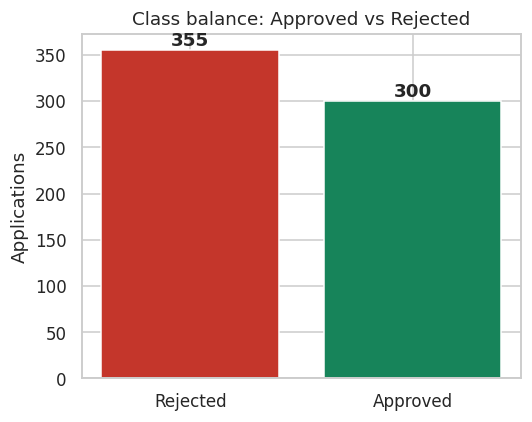

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["ApprovedLabel"].value_counts()
colors = ["#17845A" if c == "Approved" else "#C4362B" for c in counts.index]
ax.bar(counts.index, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
ax.set_title("Class balance: Approved vs Rejected")
ax.set_ylabel("Applications")
fig.tight_layout()
plt.show()


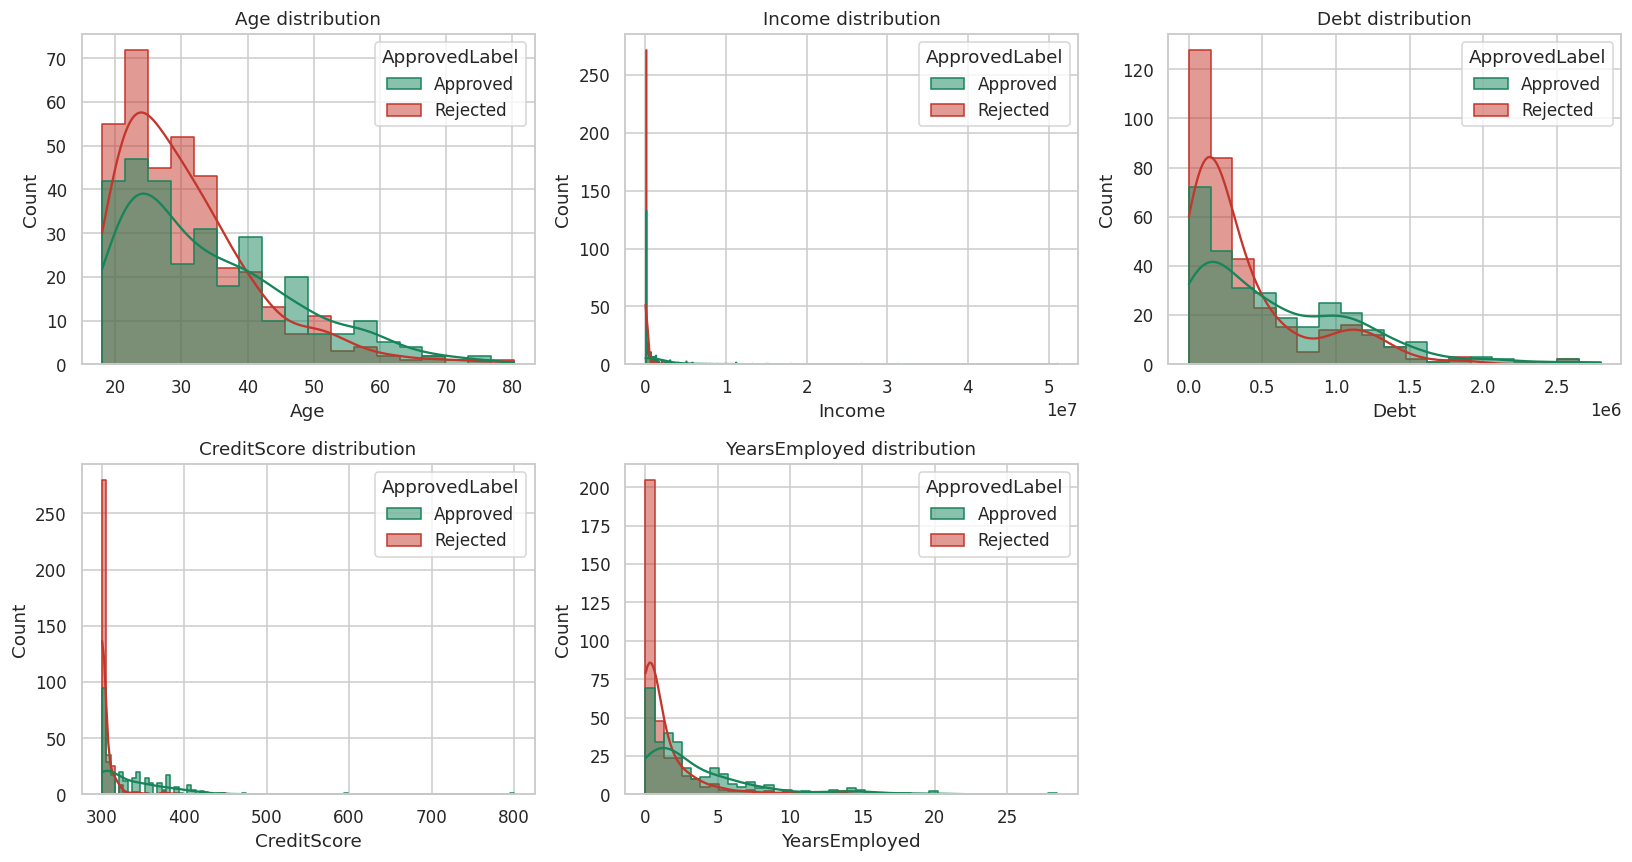

In [13]:
numeric_cols = ["Age", "Income", "Debt", "CreditScore", "YearsEmployed"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="ApprovedLabel", kde=True, ax=axes[i],
                 palette={"Approved": "#17845A", "Rejected": "#C4362B"},
                 element="step", alpha=0.5)
    axes[i].set_title(f"{col} distribution")
axes[-1].axis("off")
fig.tight_layout()
plt.show()


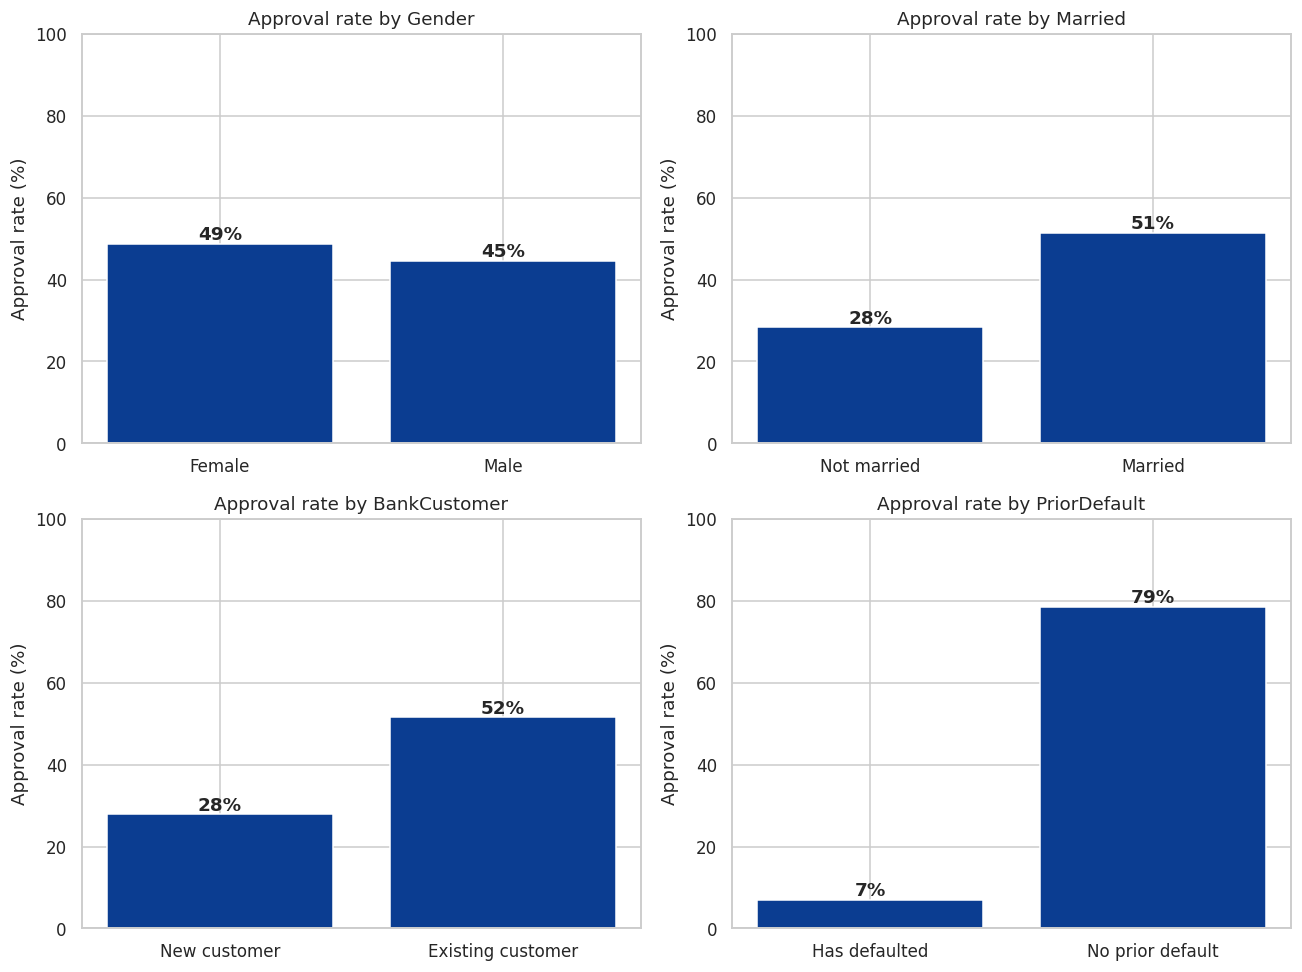

In [14]:
cat_cols = {
    "Gender": {1: "Male", 0: "Female"},
    "Married": {1: "Married", 0: "Not married"},
    "BankCustomer": {1: "Existing customer", 0: "New customer"},
    "PriorDefault": {1: "No prior default", 0: "Has defaulted"},
}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, (col, labels) in enumerate(cat_cols.items()):
    rate = df.groupby(col)["Approved"].mean().rename(index=labels) * 100
    axes[i].bar(rate.index.astype(str), rate.values, color="#0B3D91")
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
    axes[i].set_title(f"Approval rate by {col}")
    axes[i].set_ylabel("Approval rate (%)")
    axes[i].set_ylim(0, 100)
fig.tight_layout()
plt.show()


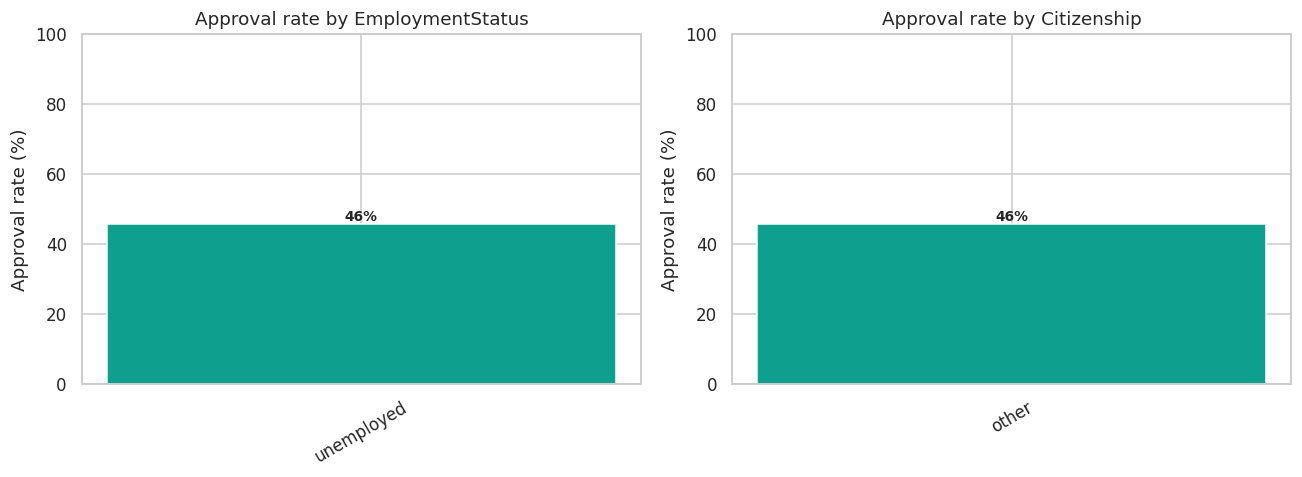

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["EmploymentStatus_label", "Citizenship_label"]):
    rate = df.groupby(col)["Approved"].mean().sort_values(ascending=False) * 100
    ax.bar(rate.index, rate.values, color="#0E9F8E")
    for j, v in enumerate(rate.values):
        ax.text(j, v + 1, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=9)
    ax.set_title(f"Approval rate by {col.replace('_label', '')}")
    ax.set_ylabel("Approval rate (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


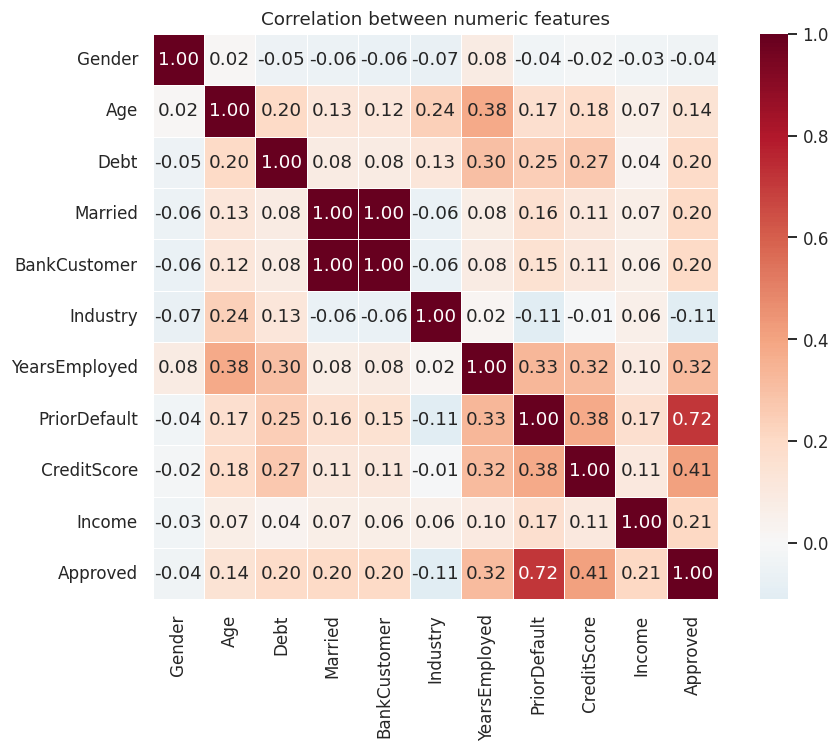

In [16]:
numeric_corr_cols = ["Gender", "Age", "Debt", "Married", "BankCustomer", "Industry",
                      "YearsEmployed", "PriorDefault", "CreditScore", "Income", "Approved"]
corr = df[numeric_corr_cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation between numeric features")
fig.tight_layout()
plt.show()


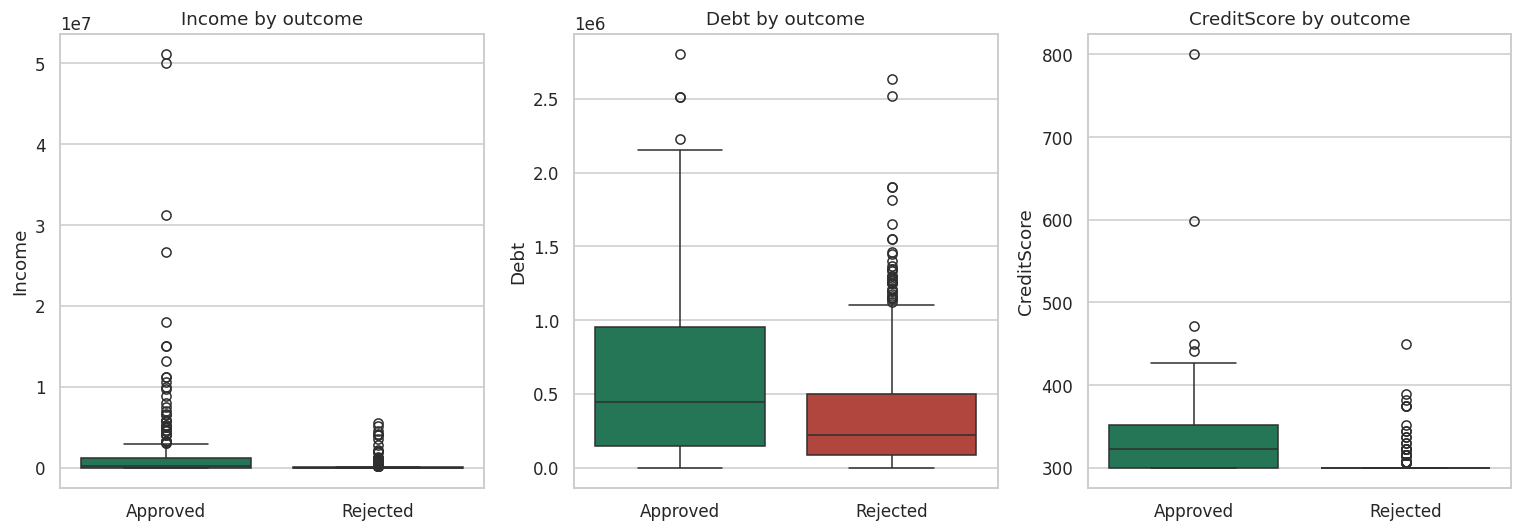

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ["Income", "Debt", "CreditScore"]):
    sns.boxplot(data=df, x="ApprovedLabel", y=col, hue="ApprovedLabel", ax=ax, legend=False,
                palette={"Approved": "#17845A", "Rejected": "#C4362B"})
    ax.set_title(f"{col} by outcome")
    ax.set_xlabel("")
fig.tight_layout()
plt.show()


In [18]:
!pip install xgboost -q

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

In [21]:
FEATURES = [
    "Gender", "Age", "Debt", "Married", "BankCustomer", "Industry",
    "YearsEmployed", "Employed", "Citizen", "PriorDefault", # Updated column names
    "CreditScore", "Income",
]


def load_and_prepare(path="cleaned_dataset.csv"):
    df = pd.read_csv(path)
    df = df.dropna()
    df = df.drop_duplicates()

    missing = [c for c in FEATURES + ["Approved"] if c not in df.columns]
    if missing:
        print(f"WARNING: {path} is missing expected column(s): {missing}")
        print(f"Columns found: {list(df.columns)}")

    if df["Debt"].max() < 1000:
        df["Debt"] = df["Debt"] * 100000
    if df["Income"].max() < 100000:
        df["Income"] = df["Income"] * 1000
    if df["CreditScore"].max() <= 100:
        df["CreditScore"] = 300 + (df["CreditScore"] / 67) * 500

    if "Employed" in df.columns: # Updated column name
        df["Employed"] = df["Employed"].astype(str).str.lower().map({
            "employed": 1, "self-employed": 1,
            "student": 0, "unemployed": 0, "retired": 0,
        }).fillna(0)
    else:
        df["Employed"] = 0

    if "Citizen" in df.columns: # Updated column name
        df["Citizen"] = df["Citizen"].astype(str).str.lower().map({
            "indian": 1, "nri": 1, "other": 0,
        }).fillna(1)
    else:
        df["Citizen"] = 1

    if "Industry" in df.columns:
        df["Industry"] = pd.to_numeric(df["Industry"], errors="coerce").fillna(0)
    else:
        df["Industry"] = 0

    for col in FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["Approved"] = pd.to_numeric(df["Approved"], errors="coerce")
    df = df.dropna()

    return df
df = load_and_prepare()
print(f"Loaded {len(df)} rows after cleaning.\n")

X = df[FEATURES]
y = df["Approved"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Loaded 655 rows after cleaning.



In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric="logloss",
    )
else:
    print("xgboost not available -- substituting HistGradientBoostingClassifier.\n")
    models["XGBoost (fallback: HistGradientBoosting)"] = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=4, random_state=42
    )

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.8626
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86        71
           1       0.79      0.95      0.86        60

    accuracy                           0.86       131
   macro avg       0.87      0.87      0.86       131
weighted avg       0.88      0.86      0.86       131

Confusion Matrix:
[[56 15]
 [ 3 57]]

--- Decision Tree ---
Accuracy: 0.7939
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82        71
           1       0.80      0.73      0.77        60

    accuracy                           0.79       131
   macro avg       0.79      0.79      0.79       131
weighted avg       0.79      0.79      0.79       131

Confusion Matrix:
[[60 11]
 [16 44]]

--- Random Forest ---
Accuracy: 0.8626
Classification Report:
              precision    recall  f1-score   support

           0       0.9

In [24]:
results = {}

for name, model in models.items():
    if "Logistic" in name:
        scaler = StandardScaler()
        X_train_fit = scaler.fit_transform(X_train)
        X_test_fit = scaler.transform(X_test)
    else:
        X_train_fit, X_test_fit = X_train, X_test

    model.fit(X_train_fit, y_train)
    y_pred = model.predict(X_test_fit)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["Rejected", "Approved"])
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"accuracy": acc, "report": report, "confusion_matrix": cm, "model": model}

    print(f"{'=' * 60}")
    print(f"{name}  —  Accuracy: {acc:.4f}")
    print(f"{'=' * 60}")
    print(report)


Logistic Regression  —  Accuracy: 0.8626
              precision    recall  f1-score   support

    Rejected       0.95      0.79      0.86        71
    Approved       0.79      0.95      0.86        60

    accuracy                           0.86       131
   macro avg       0.87      0.87      0.86       131
weighted avg       0.88      0.86      0.86       131

Decision Tree  —  Accuracy: 0.7939
              precision    recall  f1-score   support

    Rejected       0.79      0.85      0.82        71
    Approved       0.80      0.73      0.77        60

    accuracy                           0.79       131
   macro avg       0.79      0.79      0.79       131
weighted avg       0.79      0.79      0.79       131

Random Forest  —  Accuracy: 0.8626
              precision    recall  f1-score   support

    Rejected       0.91      0.83      0.87        71
    Approved       0.82      0.90      0.86        60

    accuracy                           0.86       131
   macro avg     

In [25]:
rows_ = []
for name, res in results.items():
    cm = res["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    rows_.append({
        "Model": name,
        "Accuracy": round(res["accuracy"], 4),
        "Precision (Approved)": round(precision, 4),
        "Recall (Approved)": round(recall, 4),
        "F1 (Approved)": round(f1, 4),
    })

summary = pd.DataFrame(rows_).sort_values("Accuracy", ascending=False)
print("Summary table:")
try:
    display(summary)  # Colab renders this as a nice table
except NameError:
    print(summary.to_string(index=False))  # plain-Python fallback

best = summary.iloc[0]["Model"]
print(f"\nBest performing model on this split: {best}")

Summary table:


,Model,Accuracy,Precision (Approved),Recall (Approved),F1 (Approved)
3,XGBoost,0.8702,0.8308,0.9000,0.8640
0,Logistic Regression,0.8626,0.7917,0.9500,0.8636
2,Random Forest,0.8626,0.8182,0.9000,0.8571
1,Decision Tree,0.7939,0.8000,0.7333,0.7652



Best performing model on this split: XGBoost
